In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Práctica: Análisis y Reducción de Dimensionalidad con PCA

### Descripción:
En esta práctica, utilizaremos el conjunto de datos de `Wine` proporcionado por `sklearn.datasets`, que contiene información química sobre varios tipos de vinos. El objetivo es explorar el dataset, aplicar técnicas de reducción de dimensionalidad, como PCA, y construir un modelo de clasificación eficiente basado en estas transformaciones.

### Objetivos:
1. Realizar un análisis exploratorio de los datos (EDA) para comprender la distribución de las características.
2. Aplicar el Análisis de Componentes Principales (PCA) para reducir la dimensionalidad del conjunto de datos y visualizar la varianza explicada por las componentes principales.
3. Construir un modelo de clasificación utilizando las características originales y otro usando las componentes principales seleccionadas con PCA.
4. Comparar el rendimiento de los modelos para evaluar el impacto de la reducción de dimensionalidad.

### Dataset:
El dataset `Wine` contiene 13 características químicas que describen el contenido de varios vinos, y está clasificado en 3 tipos de vinos diferentes. Las características incluyen:
- Alcohol
- Ácido málico
- Cenizas
- Alcalinidad de las cenizas
- Magnesio
- Fenoles totales
- Flavonoides
- Fenoles no flavonoides
- Proantocianinas
- Intensidad de color
- Tono
- OD280/OD315 de vinos diluidos
- Prolina

### Pasos:
1. **Exploración de los Datos:** Cargaremos y visualizaremos los datos, observando la distribución de las características y la correlación entre ellas.
2. **Aplicación de PCA:** Reduciremos la dimensionalidad de los datos y analizaremos la varianza explicada por las componentes principales.
3. **Modelos de Clasificación:** Entrenaremos un modelo de clasificación antes y después de aplicar PCA para comparar su rendimiento.


## Etapa 1: Exploración de los Datos

### Objetivo:
En esta primera etapa, vamos a cargar el conjunto de datos de `Wine`, visualizar las primeras filas, y realizar un análisis exploratorio de los datos (EDA). Esto nos permitirá entender mejor la estructura y distribución de las características, así como las relaciones entre las mismas.

### Instrucciones:
1. Cargar el conjunto de datos de `Wine` desde `sklearn.datasets`.
2. Mostrar las primeras filas del conjunto de datos para familiarizarnos con las características.
3. Realizar un análisis exploratorio de los datos, visualizando la distribución de las características a través de histogramas y observando las correlaciones mediante una matriz de correlación.
4. Visualizar las clases de vinos presentes en el conjunto de datos.

### Visualizaciones:
- Histogramas de las características para observar su distribución.
- Matriz de correlación para identificar relaciones entre las variables.


Aquí cargaremos el dataset de Wine y realizaremos un análisis exploratorio básico.

In [2]:
# Importar las bibliotecas necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Cargar el dataset de Wine
wine_data = load_wine()
X_wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y_wine = pd.Series(wine_data.target, name='target')

# Unir los datos y las etiquetas en un solo DataFrame para el análisis exploratorio
df_wine = pd.concat([X_wine, y_wine], axis=1)

# Mostrar las primeras filas del dataset
df_wine.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Generemos histogramas de las características y una matriz de correlación.

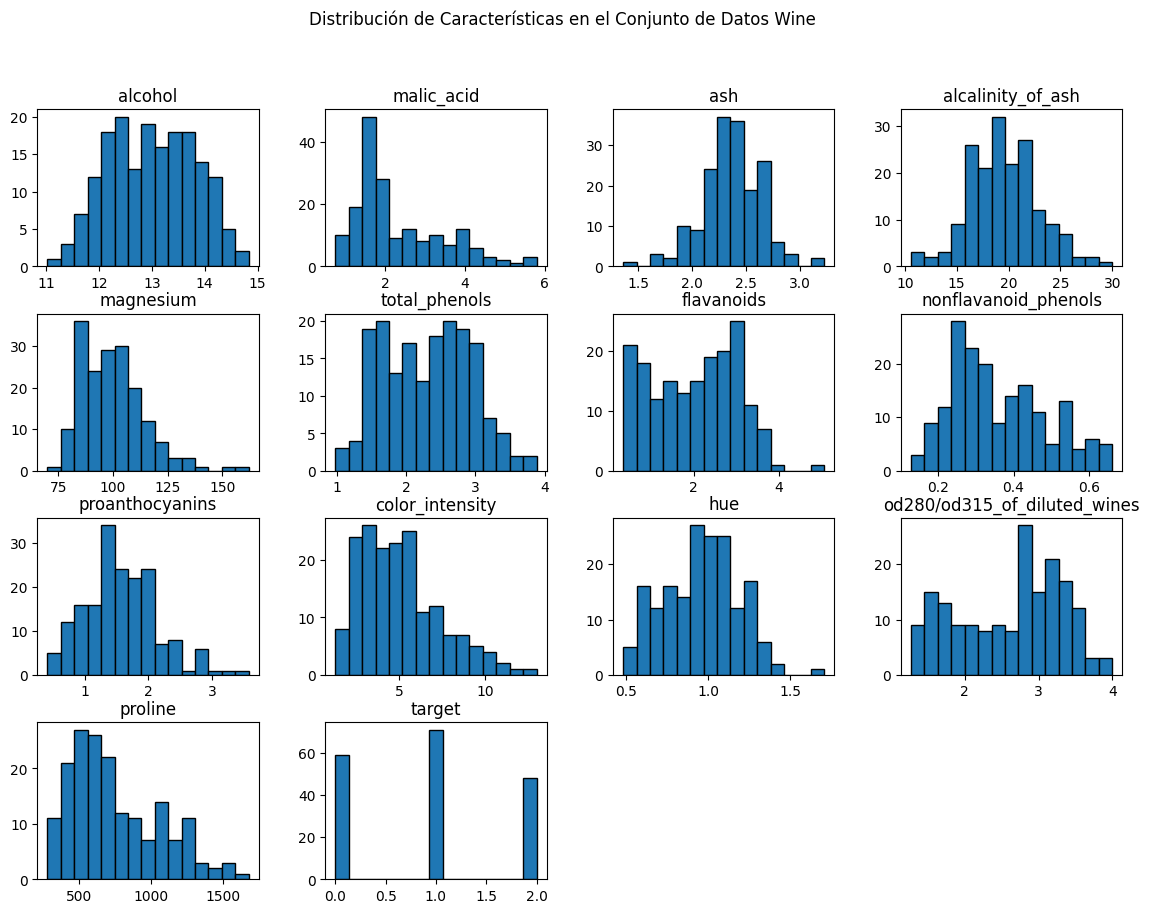

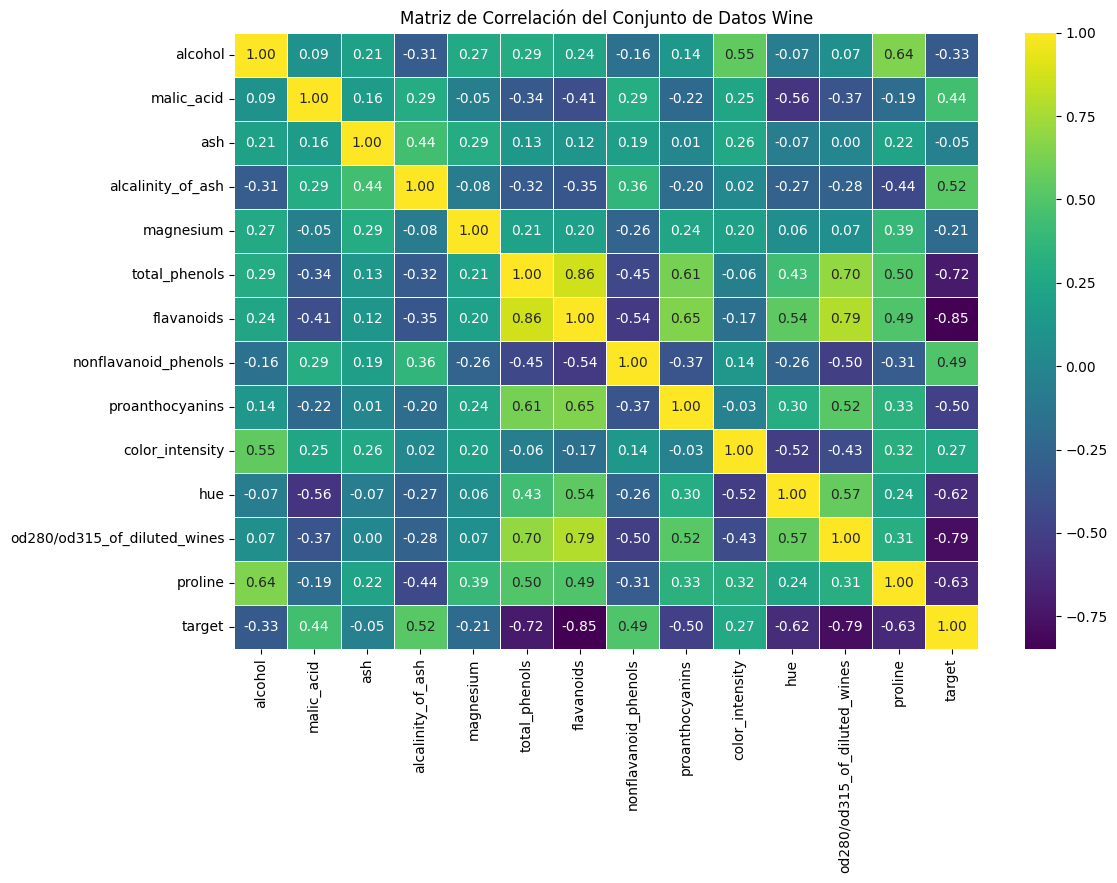

In [3]:
# Visualización de los histogramas de las características
df_wine.hist(bins=15, figsize=(14, 10), grid=False, edgecolor='black')
plt.suptitle("Distribución de Características en el Conjunto de Datos Wine")
plt.show()

# Matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(df_wine.corr(), annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title("Matriz de Correlación del Conjunto de Datos Wine")
plt.show()


Hemos generado los histogramas de las características del conjunto de datos de Wine, así como la matriz de correlación. Estas visualizaciones nos permiten comprender mejor la distribución de las variables y las relaciones entre ellas.
Como podemos observar, hay varias características que tienen datos correlacionados

## Etapa 2: Aplicación de PCA Inicial

### Objetivo:
En esta etapa, aplicaremos el Análisis de Componentes Principales (PCA) al conjunto de datos de `Wine`. El objetivo es visualizar cuánta varianza es explicada por cada componente principal y decidir cuántas componentes principales retener para capturar la mayor parte de la variabilidad en los datos.

### Instrucciones:
1. Aplicar PCA al conjunto de datos completo de `Wine` (sin normalizar, ya que PCA se ve afectado por las escalas de las variables).
2. Visualizar la varianza explicada por cada componente principal mediante un **Scree Plot** (gráfico de codo) y la varianza acumulada.
3. Decidir cuántas componentes principales retener con base en el análisis de la varianza.

### Visualizaciones:
- **Scree Plot**: Muestra la cantidad de varianza explicada por cada componente principal.
- **Varianza acumulada**: Un gráfico que muestra cómo la varianza total se acumula con el número de componentes.


1. Aplicar PCA y calcular la varianza explicada por componente principal.

In [4]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_wine)

# Varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Mostrar la varianza explicada por cada componente
explained_variance


array([9.98091230e-01, 1.73591562e-03, 9.49589576e-05, 5.02173562e-05,
       1.23636847e-05, 8.46213034e-06, 2.80681456e-06, 1.52308053e-06,
       1.12783044e-06, 7.21415811e-07, 3.78060267e-07, 2.12013755e-07,
       8.25392788e-08])

La varianza explicada por cada componente principal ha sido calculada. El primer componente principal captura el 99.8% de la varianza, mientras que los siguientes componentes explican cada vez menos varianza.

2. Ahora visualizaremos esta información mediante un gráfico de varianza acumulada (Scree Plot) para ver cuántos componentes principales retener.

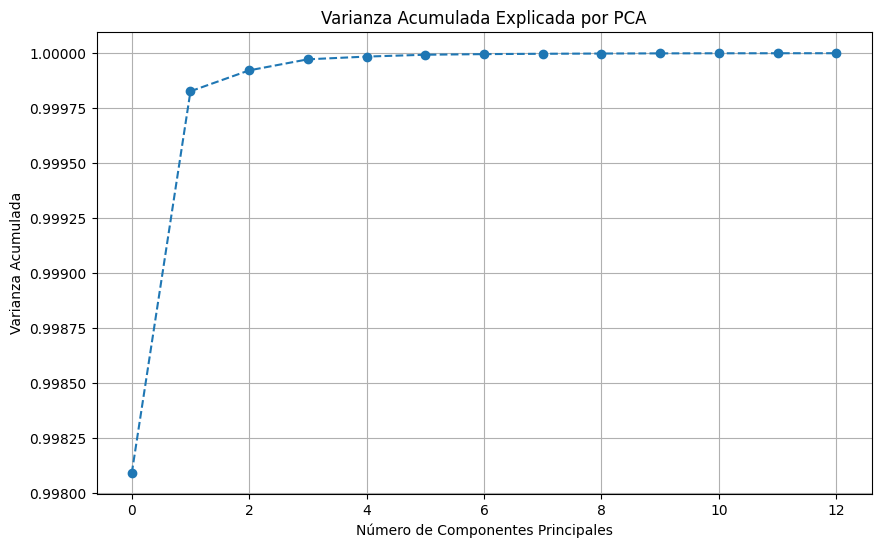

In [5]:
# Gráfico de Codo (Scree Plot) de la varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(explained_variance), marker='o', linestyle='--')
plt.title('Varianza Acumulada Explicada por PCA')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.show()


El gráfico de varianza acumulada muestra cómo se distribuye la varianza a través de los componentes principales. Podemos ver que la mayoría de la varianza es capturada por el primer componente, y las siguientes componentes añaden una pequeña cantidad de varianza.

3. Ahora, crearemos un gráfico de barras que muestre la varianza explicada por cada componente principal de manera individual, junto con la varianza acumulada.

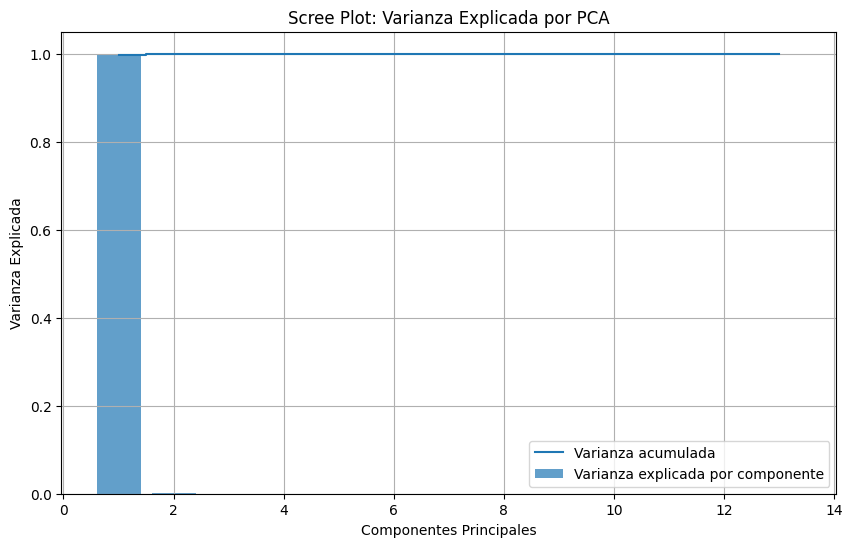

In [6]:
# Visualización de la varianza explicada por cada componente principal
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align='center', label='Varianza explicada por componente')
plt.step(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), where='mid', label='Varianza acumulada')
plt.title('Scree Plot: Varianza Explicada por PCA')
plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.legend(loc='best')
plt.grid(True)
plt.show()


El gráfico de barras muestra la varianza explicada por cada componente principal junto con la línea de varianza acumulada. A partir de este gráfico, podemos observar que el primer componente principal explica casi toda la varianza, mientras que los siguientes componentes agregan una pequeña cantidad de varianza adicional.

## Etapa 3: Reducción de Dimensionalidad con PCA

### Objetivo:
En esta etapa, vamos a proyectar los datos en las componentes principales seleccionadas. Esto nos permitirá reducir la dimensionalidad del conjunto de datos y visualizarlo en un espacio de 2 o 3 dimensiones, manteniendo la mayor parte de la varianza.

### Instrucciones:
1. Proyectar los datos en las componentes principales seleccionadas (por ejemplo, las primeras 2 componentes para visualización en 2D y 3D).
2. Visualizar los datos proyectados en las nuevas componentes principales.
3. Identificar si las clases (tipos de vino) son separables en este espacio reducido.

### Visualizaciones:
- Gráfico 2D de los datos proyectados en las 2 primeras componentes principales, coloreados por clase (target).
- Gráfico 3D de los datos proyectados en las 3 primeras componentes principales.


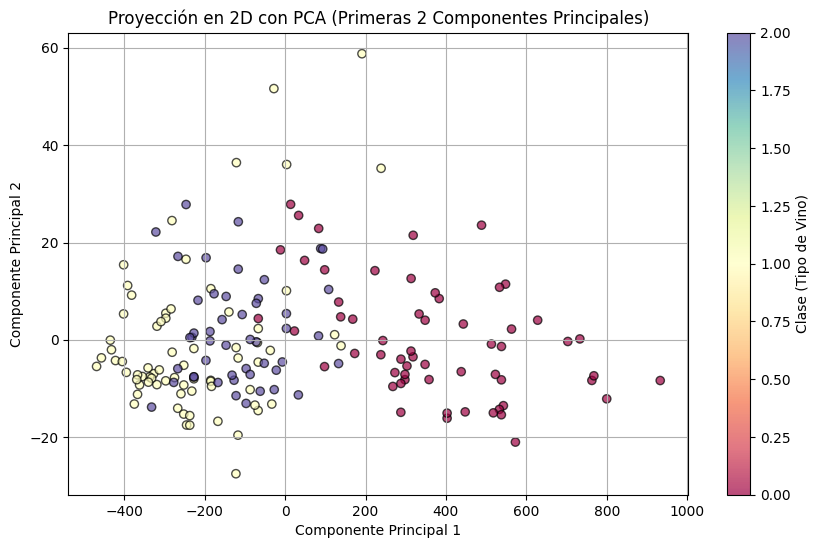

In [7]:
# Proyección de los datos en las dos primeras componentes principales
X_pca_2d = X_pca[:, :2]  # Tomar solo las dos primeras componentes

# Visualización en 2D de las dos primeras componentes principales
plt.figure(figsize=(10, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=wine_data.target, cmap='Spectral', edgecolor='k', alpha=0.7)
plt.title('Proyección en 2D con PCA (Primeras 2 Componentes Principales)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(label='Clase (Tipo de Vino)')
plt.grid(True)
plt.show()


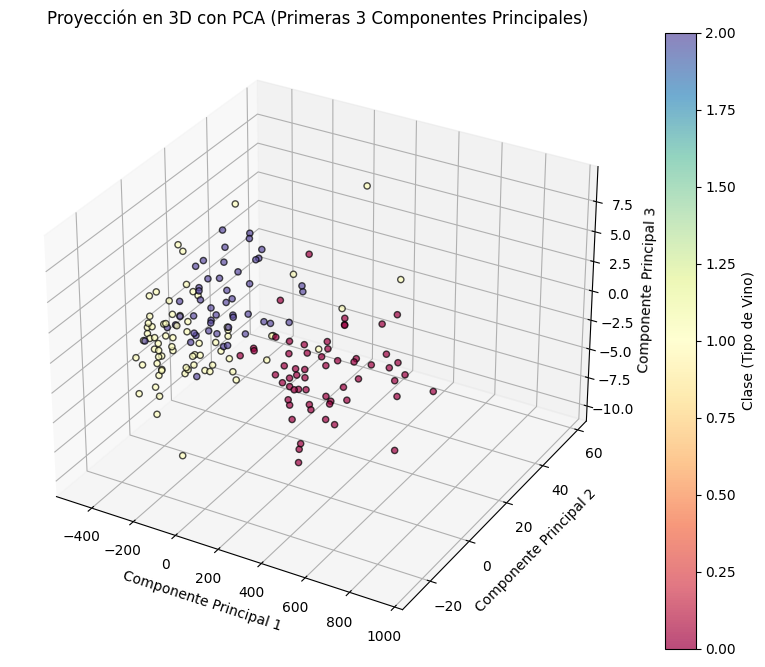

In [8]:
from mpl_toolkits.mplot3d import Axes3D

# Proyección de los datos en las primeras 3 componentes principales
X_pca_3d = X_pca[:, :3]  # Tomar las primeras tres componentes

# Visualización en 3D de las tres primeras componentes principales
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=wine_data.target, cmap='Spectral', edgecolor='k', alpha=0.7)
ax.set_title('Proyección en 3D con PCA (Primeras 3 Componentes Principales)')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
fig.colorbar(sc, label='Clase (Tipo de Vino)')
plt.show()


## Etapa 4: Modelos de Clasificación sin Reducción de Dimensionalidad

### Objetivo:
En esta etapa, entrenaremos varios modelos de clasificación (Logistic Regression, Decision Tree, Random Forest) utilizando todas las características originales del conjunto de datos, sin reducción de dimensionalidad. Esto nos permitirá tener una línea de base para comparar el rendimiento después de aplicar PCA.

### Instrucciones:
1. Dividir el conjunto de datos en entrenamiento y prueba.
2. Entrenar los siguientes modelos de clasificación:
   - **Regresión Logística**
   - **Árbol de Decisión**
   - **Random Forest**
3. Evaluar el rendimiento de cada modelo en el conjunto de prueba usando:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1-score**
4. Mostrar la **matriz de confusión** y el **reporte de clasificación** para cada modelo.
5. Comparar los resultados obtenidos.

### Métricas de Evaluación:
- **Accuracy**: Proporción de predicciones correctas sobre el total.
- **Precision**: Proporción de verdaderos positivos sobre todos los casos positivos predichos.
- **Recall**: Proporción de verdaderos positivos sobre todos los casos positivos reales.
- **F1-score**: Media armónica de precision y recall.

### Visualizaciones:
- **Matriz de Confusión**: Para analizar el rendimiento del modelo en cada clase.
- **Reporte de Clasificación**: Para observar precisión, recall y F1-score por clase.


--- Logistic Regression ---
Accuracy: 0.9841
Precision: 0.9847
Recall: 0.9841
F1 Score: 0.9841


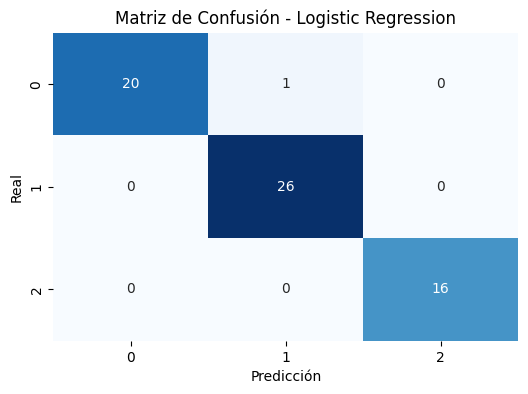

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       1.00      0.95      0.98        21
     class_1       0.96      1.00      0.98        26
     class_2       1.00      1.00      1.00        16

    accuracy                           0.98        63
   macro avg       0.99      0.98      0.99        63
weighted avg       0.98      0.98      0.98        63



--- Decision Tree ---
Accuracy: 0.9365
Precision: 0.9398
Recall: 0.9365
F1 Score: 0.9360


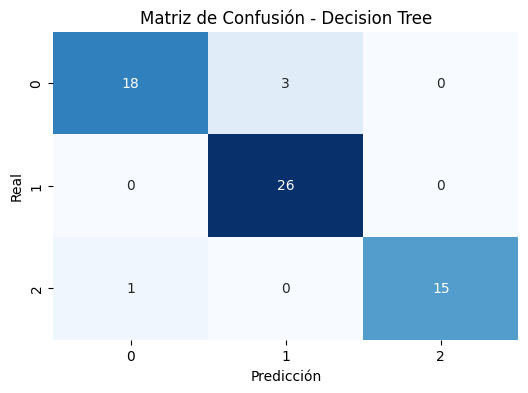

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.95      0.86      0.90        21
     class_1       0.90      1.00      0.95        26
     class_2       1.00      0.94      0.97        16

    accuracy                           0.94        63
   macro avg       0.95      0.93      0.94        63
weighted avg       0.94      0.94      0.94        63



--- Random Forest ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


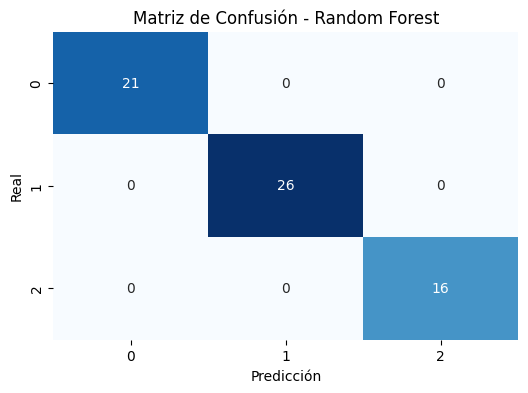

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        21
     class_1       1.00      1.00      1.00        26
     class_2       1.00      1.00      1.00        16

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63





In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_wine, wine_data.target, test_size=0.35, random_state=42)

# Entrenar y evaluar cada modelo
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Iterar sobre cada modelo
for name, model in models.items():
    print(f"--- {name} ---")

    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Predicción
    y_pred = model.predict(X_test)

    # Mostrar métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Matriz de confusión
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    # Reporte de clasificación
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=wine_data.target_names))
    print("\n")


Se puede observar que el RandomForest, mejoró la performance con respecto a los anteriores.

## Etapa 5: Modelo de Clasificación con Reducción de Dimensionalidad mediante PCA

### Objetivo:
En esta etapa, entrenaremos los mismos modelos de clasificación (Logistic Regression, Decision Tree, Random Forest) pero ahora utilizando las componentes principales seleccionadas mediante PCA. El objetivo es comparar el rendimiento de los modelos después de la reducción de dimensionalidad con el rendimiento obtenido en la **Etapa 4**.

### Instrucciones:
1. Aplicar PCA al conjunto de datos para reducir las dimensiones.
2. Proyectar los datos en las componentes principales seleccionadas.
3. Entrenar los siguientes modelos de clasificación utilizando los datos reducidos:
   - **Regresión Logística**
   - **Árbol de Decisión**
   - **Random Forest**
4. Evaluar el rendimiento de cada modelo en el conjunto de prueba usando:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1-score**
5. Mostrar la **matriz de confusión** y el **reporte de clasificación** para cada modelo.
6. Comparar los resultados con la **Etapa 4** para ver si la reducción de dimensionalidad mejora el rendimiento.

### Métricas de Evaluación:
- **Accuracy**: Proporción de predicciones correctas sobre el total.
- **Precision**: Proporción de verdaderos positivos sobre todos los casos positivos predichos.
- **Recall**: Proporción de verdaderos positivos sobre todos los casos positivos reales.
- **F1-score**: Media armónica de precision y recall.

### Visualizaciones:
- **Matriz de Confusión**: Para analizar el rendimiento del modelo en cada clase.
- **Reporte de Clasificación**: Para observar precisión, recall y F1-score por clase.


--- Logistic Regression (con PCA) ---
Accuracy: 0.7143
Precision: 0.7022
Recall: 0.7143
F1 Score: 0.7075


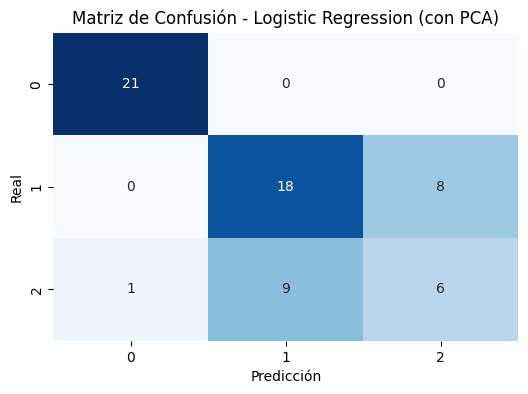

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.98        21
     class_1       0.67      0.69      0.68        26
     class_2       0.43      0.38      0.40        16

    accuracy                           0.71        63
   macro avg       0.68      0.69      0.69        63
weighted avg       0.70      0.71      0.71        63



--- Decision Tree (con PCA) ---
Accuracy: 0.6190
Precision: 0.5988
Recall: 0.6190
F1 Score: 0.6061


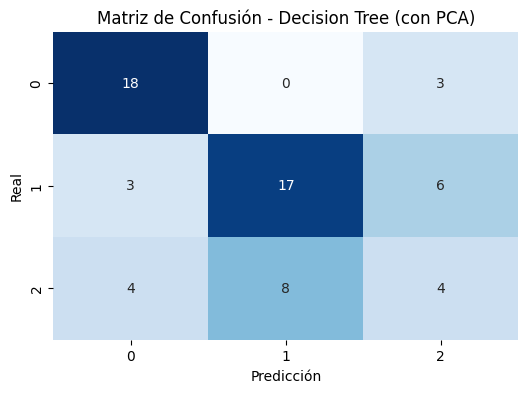

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.72      0.86      0.78        21
     class_1       0.68      0.65      0.67        26
     class_2       0.31      0.25      0.28        16

    accuracy                           0.62        63
   macro avg       0.57      0.59      0.58        63
weighted avg       0.60      0.62      0.61        63



--- Random Forest (con PCA) ---
Accuracy: 0.7460
Precision: 0.7559
Recall: 0.7460
F1 Score: 0.7500


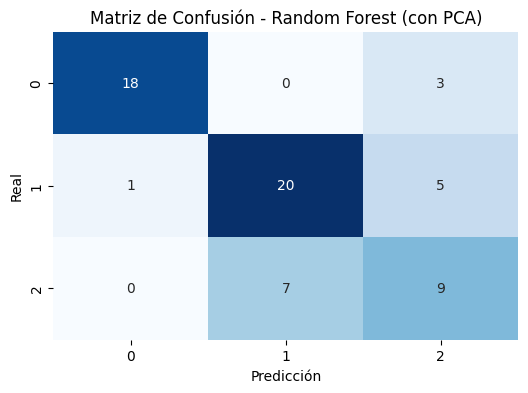

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.95      0.86      0.90        21
     class_1       0.74      0.77      0.75        26
     class_2       0.53      0.56      0.55        16

    accuracy                           0.75        63
   macro avg       0.74      0.73      0.73        63
weighted avg       0.76      0.75      0.75        63





In [10]:
# Seleccionar el número de componentes que retendremos con PCA
pca = PCA(n_components=2)  # Podemos ajustar el número de componentes a 2 para visualización
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Entrenar y evaluar cada modelo usando los datos reducidos por PCA
for name, model in models.items():
    print(f"--- {name} (con PCA) ---")

    # Entrenar el modelo
    model.fit(X_train_pca, y_train)

    # Predicción
    y_pred_pca = model.predict(X_test_pca)

    # Mostrar métricas
    accuracy = accuracy_score(y_test, y_pred_pca)
    precision = precision_score(y_test, y_pred_pca, average='weighted')
    recall = recall_score(y_test, y_pred_pca, average='weighted')
    f1 = f1_score(y_test, y_pred_pca, average='weighted')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Matriz de confusión
    conf_matrix_pca = confusion_matrix(y_test, y_pred_pca)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix_pca, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {name} (con PCA)')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    # Reporte de clasificación
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred_pca, target_names=wine_data.target_names))
    print("\n")


## Etapa 6: Ajustes y Optimización del Número de Componentes Principales

### Objetivo:
En esta etapa, ajustaremos el número de componentes principales para observar cómo afecta al rendimiento de los modelos de clasificación. Probaremos diferentes cantidades de componentes principales y evaluaremos el impacto en las métricas de rendimiento de cada modelo.

### Instrucciones:
1. Probar diferentes cantidades de componentes principales (por ejemplo, de 2 a 10).
2. Entrenar los modelos de clasificación (Regresión Logística, Árbol de Decisión, Random Forest) para cada número de componentes principales.
3. Evaluar el rendimiento de cada modelo con cada ajuste.
4. Visualizar cómo cambia el rendimiento (accuracy, precision, recall, F1-score) en función del número de componentes seleccionados.
5. Determinar el número óptimo de componentes principales en función del rendimiento del modelo.

### Visualizaciones:
- Gráfico que muestre el cambio en las métricas de rendimiento (accuracy, precision, recall, F1-score) en función del número de componentes principales seleccionados.


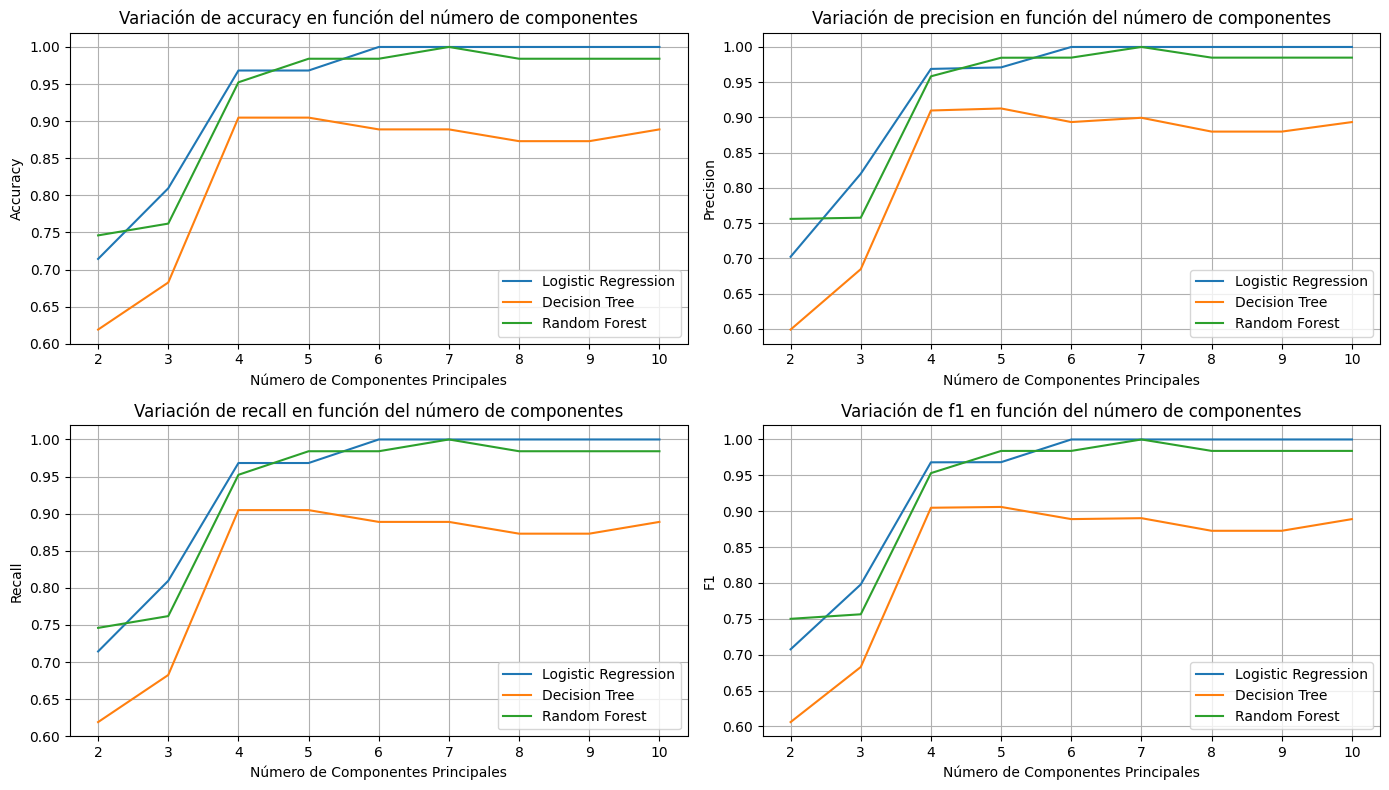

In [11]:
# Vamos a probar entre 2 y 10 componentes principales
n_components_range = range(2, 11)
results = {
    'Logistic Regression': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
    'Decision Tree': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
    'Random Forest': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
}

# Iterar sobre diferentes números de componentes principales
for n_components in n_components_range:
    # Aplicar PCA con n componentes
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Entrenar y evaluar cada modelo con el número actual de componentes
    for name, model in models.items():
        model.fit(X_train_pca, y_train)
        y_pred_pca = model.predict(X_test_pca)

        # Calcular métricas
        accuracy = accuracy_score(y_test, y_pred_pca)
        precision = precision_score(y_test, y_pred_pca, average='weighted')
        recall = recall_score(y_test, y_pred_pca, average='weighted')
        f1 = f1_score(y_test, y_pred_pca, average='weighted')

        # Almacenar los resultados
        results[name]['accuracy'].append(accuracy)
        results[name]['precision'].append(precision)
        results[name]['recall'].append(recall)
        results[name]['f1'].append(f1)

# Visualización de los resultados
plt.figure(figsize=(14, 8))
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    plt.subplot(2, 2, list(['accuracy', 'precision', 'recall', 'f1']).index(metric) + 1)
    for name in models.keys():
        plt.plot(n_components_range, results[name][metric], label=name)
    plt.title(f'Variación de {metric} en función del número de componentes')
    plt.xlabel('Número de Componentes Principales')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()


El gráfico muestra cómo varían las métricas de rendimiento (accuracy, precision, recall y F1-score) en función del número de componentes principales seleccionados para cada uno de los tres modelos: Logistic Regression, Decision Tree, y Random Forest.

Esto permite visualizar claramente cómo el número de componentes influye en el rendimiento de cada modelo, ayudando a identificar cuántos componentes principales son óptimos para maximizar el rendimiento.